# Used Car Price-Value Ratio Arbitrage Study

**Question:** Which used cars in the SGD $60K–$80K bracket offer the best value?

**Data:** Used car listings from SGCarMart, fetched 2026-05-23.
Filters: 2016+ registration, passenger cars only, COE-renewed cars excluded.

In [1]:
import json, re
from datetime import datetime, date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_FILE = PROJECT_ROOT / "data/used_cars/sgd-60k-80k-newest/latest.json"
CONFIG_FILE = PROJECT_ROOT / "data/used_cars/sgd-60k-80k-newest/config.json"

with open(CONFIG_FILE) as f:
    watch_config = json.load(f)
print("Watch config:", json.dumps(watch_config, indent=2))

Watch config: {
  "name": "sgd-60k-80k-newest",
  "filters": {
    "min_price": 60000,
    "max_price": 80000,
    "year_from": 2016,
    "vts": 2,
    "avl": "a",
    "sortby": "REG_DESC",
    "limit": 100
  },
  "max_pages": 50,
  "exclude_coe_renewed": true
}


In [2]:
with open(DATA_FILE) as f:
    raw = json.load(f)

listings = list(raw.values())
print(f"Loaded {len(listings)} listings")

# Derive reference date from the data itself
TODAY = datetime.strptime(listings[0]["posted_date"], "%d-%b-%Y").date()
YEAR_FROM = TODAY.year - 10
print(f"Reference date: {TODAY}, year_from: {YEAR_FROM}")
print(f"Fields: {list(listings[0].keys())}")

Loaded 1146 listings
Reference date: 2026-05-21, year_from: 2016
Fields: ['id', 'title', 'url', 'price', 'depreciation', 'reg_date', 'coe_left', 'mileage', 'eng_cap', 'owners', 'is_direct_owner', 'is_premium_ad', 'dealer', 'posted_date', 'description']


In [3]:
def parse_coe_left(text):
    if not text: return None
    years = 0.0
    y_match = re.search(r'(\d+)\s*y', text)
    m_match = re.search(r'(\d+)\s*m', text)
    if y_match: years += int(y_match.group(1))
    if m_match: years += int(m_match.group(1)) / 12
    return years if years > 0 else None

def parse_mileage(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_eng_cap(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_owners(text):
    if not text: return None
    if 'more than' in text.lower():
        m = re.search(r'\d+', text)
        return int(m.group()) + 1 if m else None
    m = re.search(r'(\d+)\s*Owner', text)
    return int(m.group(1)) if m else None

def parse_reg_date(text):
    if not text: return None
    try: return datetime.strptime(text, '%d-%b-%Y').date()
    except ValueError: return None

def extract_brand(title):
    return title.split()[0] if title else ''

print('Parse functions ready.')

Parse functions ready.


In [4]:
rows = []
for car in listings:
    reg_date = parse_reg_date(car.get('reg_date'))
    age = (TODAY - reg_date).days / 365.25 if reg_date else None
    rows.append({
        'id': car['id'], 'title': car['title'],
        'brand': extract_brand(car['title']),
        'price': car.get('price'), 'depreciation': car.get('depreciation'),
        'reg_date': reg_date, 'age_years': age,
        'coe_years_left': parse_coe_left(car.get('coe_left')),
        'mileage_km': parse_mileage(car.get('mileage')),
        'eng_cap_cc': parse_eng_cap(car.get('eng_cap')),
        'num_owners': parse_owners(car.get('owners')),
        'is_direct_owner': car.get('is_direct_owner', False),
        'is_premium_ad': car.get('is_premium_ad', False),
    })

df = pd.DataFrame(rows)
print(f"DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nBasic stats:")
print(df[['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km', 'eng_cap_cc', 'num_owners']].describe())

DataFrame: 1146 rows, 13 columns

Null counts:
id                   0
title                0
brand                0
price                0
depreciation        16
reg_date             0
age_years            0
coe_years_left       4
mileage_km         107
eng_cap_cc          13
num_owners           1
is_direct_owner      0
is_premium_ad        0
dtype: int64

Basic stats:
              price  depreciation    age_years  coe_years_left     mileage_km  \
count   1146.000000   1130.000000  1146.000000     1142.000000    1039.000000   
mean   70181.000000  18629.539823     6.943137        3.025540   95014.976901   
std     5940.583584   4214.674054     1.106575        1.092580   28911.975335   
min    60000.000000  10640.000000     3.052704        0.166667   20900.000000   
25%    64800.000000  15772.500000     6.264887        2.250000   76000.000000   
50%    69888.000000  17815.000000     6.924025        3.000000   92300.000000   
75%    75800.000000  20525.000000     7.746749        3.6666

In [5]:
df['depreciation_rate'] = df['depreciation'] / df['price']
df['est_original_price'] = df['price'] + (df['depreciation'] * df['age_years'])
df['value_retention'] = df['price'] / df['est_original_price']
df['price_per_coe_year'] = df['price'] / df['coe_years_left']
df['depreciation_per_cc'] = df['depreciation'] / df['eng_cap_cc']

df['suspicious'] = (
    (df['value_retention'] > 1.5) | (df['value_retention'] < 0.1) |
    (df['depreciation_rate'] > 1.0) | (df['age_years'] < 0)
)

print(f"Suspicious rows: {df['suspicious'].sum()} / {len(df)}")
clean = df[~df['suspicious'] & df['price'].notna() & df['depreciation'].notna()].copy()
print(f"Clean dataset: {len(clean)} listings")
print("\nValue characteristics summary:")
print(clean[['depreciation_rate', 'value_retention', 'price_per_coe_year', 'depreciation_per_cc']].describe())

Suspicious rows: 0 / 1146
Clean dataset: 1130 listings

Value characteristics summary:
       depreciation_rate  value_retention  price_per_coe_year  \
count        1130.000000      1130.000000         1130.000000   
mean            0.266927         0.363713        26854.477892   
std             0.062133         0.082160        13228.667866   
min             0.151000         0.126912        12000.000000   
25%             0.224848         0.305430        18613.333333   
50%             0.257685         0.358465        22869.475936   
75%             0.295996         0.415278        30702.055556   
max             0.735795         0.662365       136971.428571   

       depreciation_per_cc  
count          1117.000000  
mean             11.111989  
std               2.159506  
min               5.597983  
25%               9.609610  
50%              10.790791  
75%              12.048032  
max              29.409705  


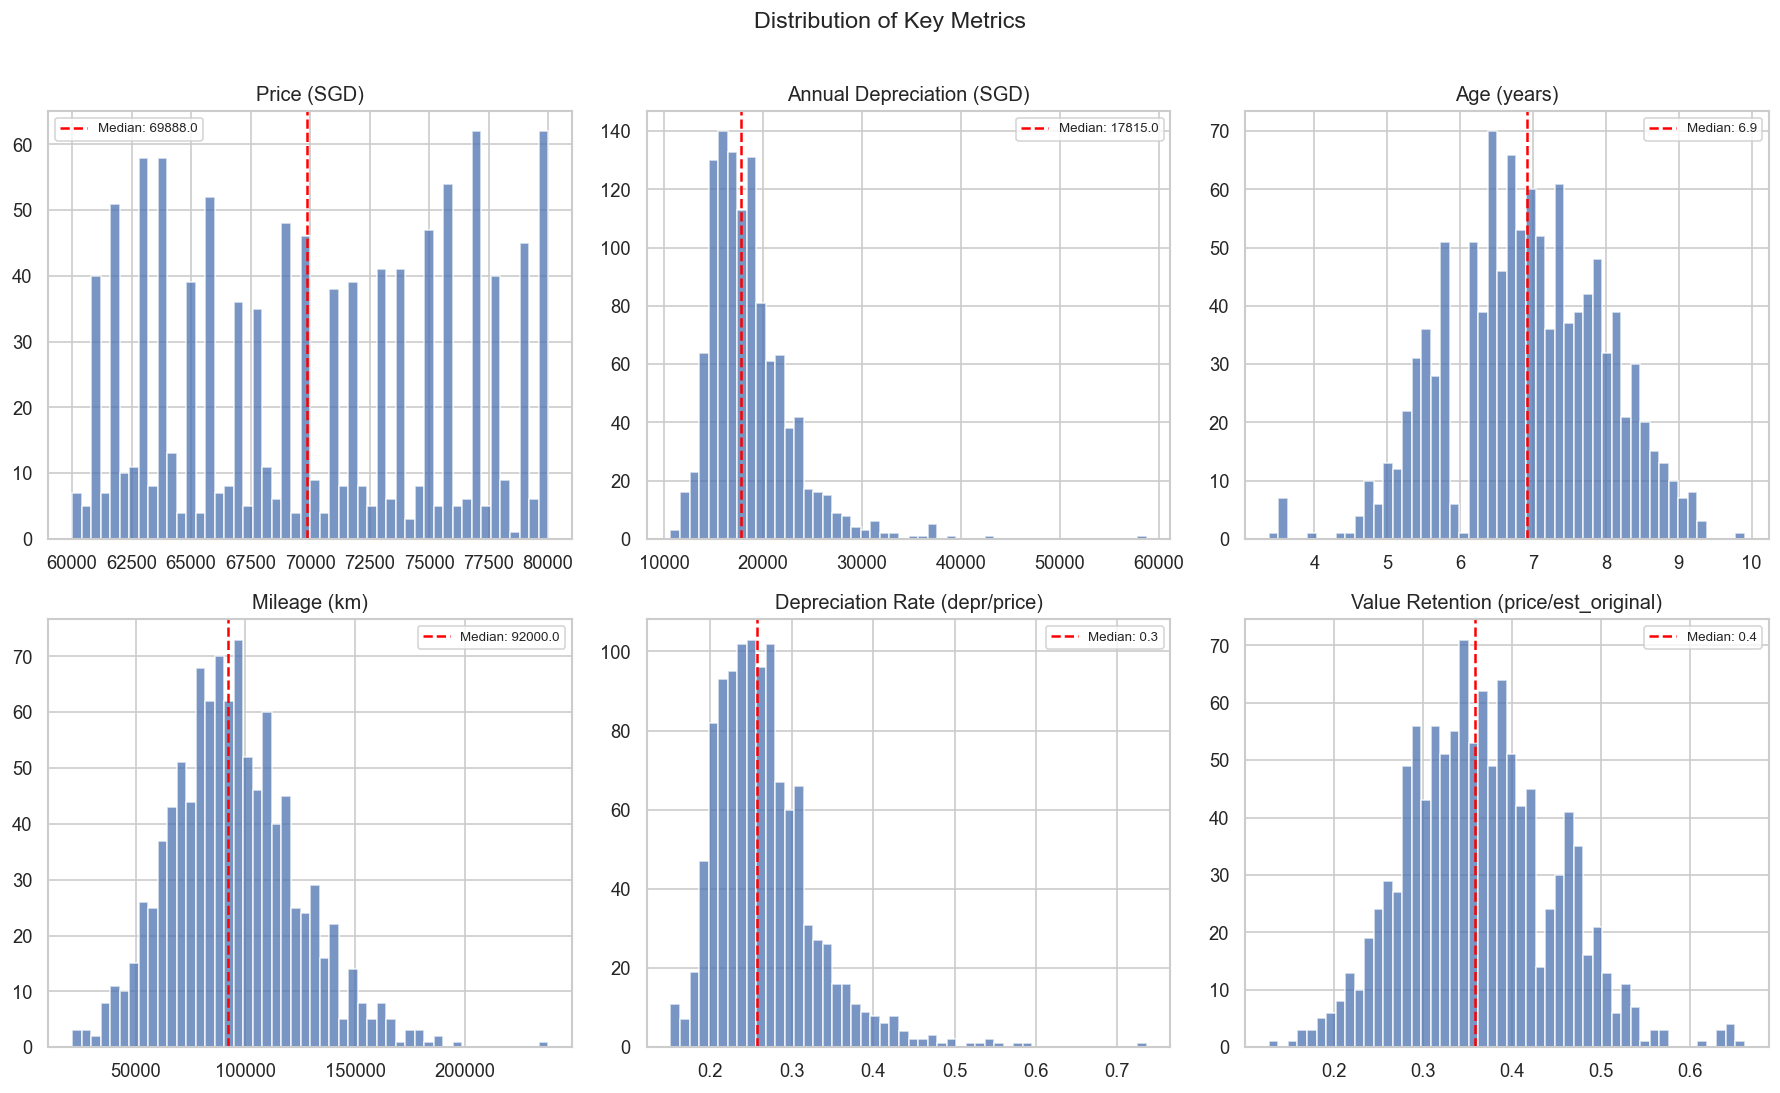

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
metrics = [
    ('price', 'Price (SGD)'), ('depreciation', 'Annual Depreciation (SGD)'),
    ('age_years', 'Age (years)'), ('mileage_km', 'Mileage (km)'),
    ('depreciation_rate', 'Depreciation Rate (depr/price)'),
    ('value_retention', 'Value Retention (price/est_original)'),
]
for ax, (col, label) in zip(axes, metrics):
    data = clean[col].dropna()
    ax.hist(data, bins=50, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(label); ax.legend(fontsize=8)
fig.suptitle('Distribution of Key Metrics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

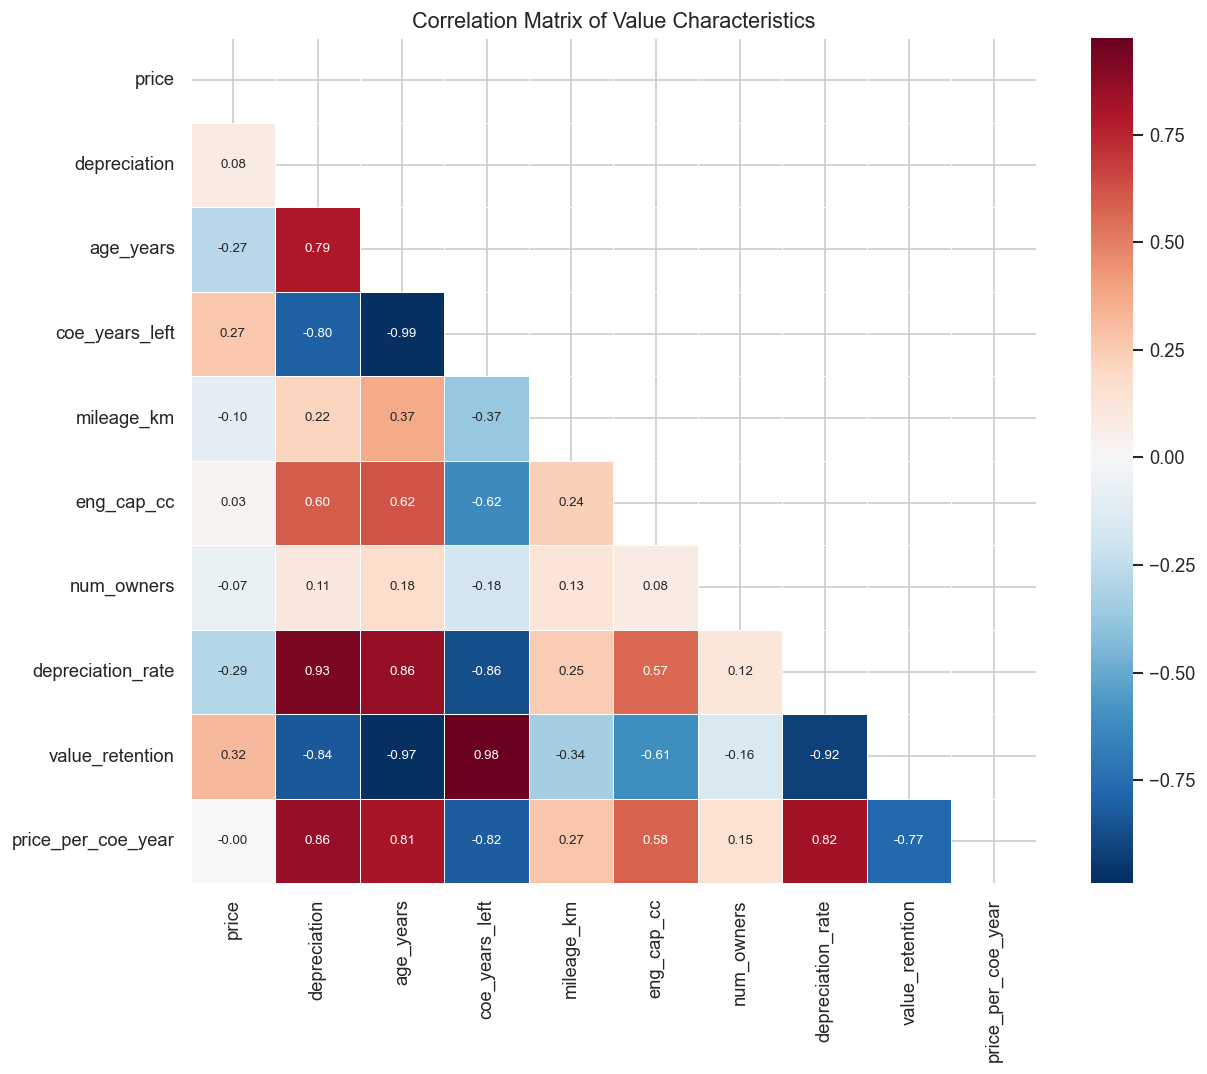

In [7]:
corr_cols = ['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km',
             'eng_cap_cc', 'num_owners', 'depreciation_rate', 'value_retention',
             'price_per_coe_year']
corr = clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Correlation Matrix of Value Characteristics', fontsize=13)
plt.tight_layout(); plt.show()

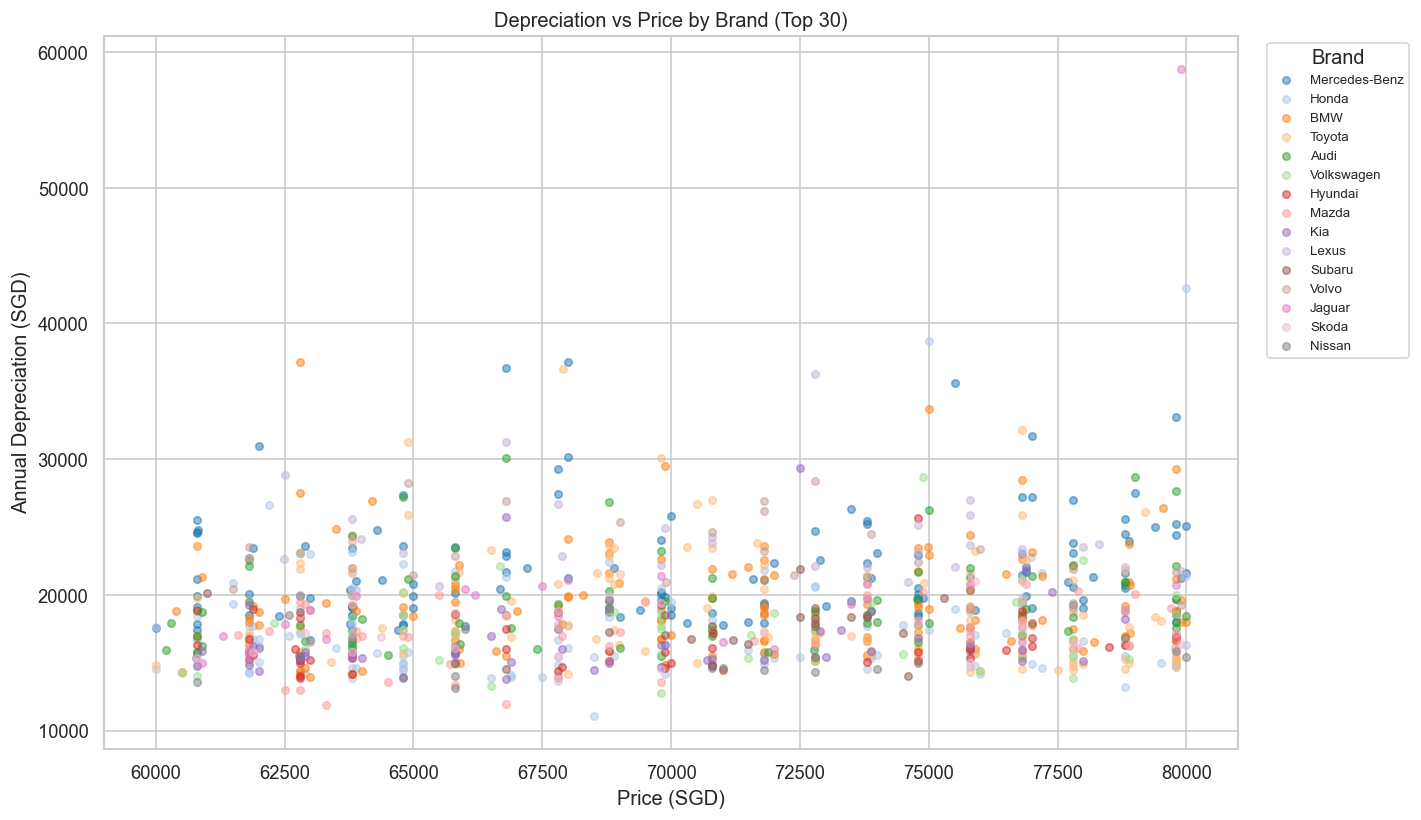

In [8]:
top_brands = clean['brand'].value_counts().head(15).index
plot_df = clean[clean['brand'].isin(top_brands)]
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('tab20', len(top_brands))
for i, brand in enumerate(top_brands):
    brand_data = plot_df[plot_df['brand'] == brand]
    ax.scatter(brand_data['price'], brand_data['depreciation'],
               c=[colors[i]], label=brand, alpha=0.5, s=20)
ax.set_xlabel('Price (SGD)'); ax.set_ylabel('Annual Depreciation (SGD)')
ax.set_title('Depreciation vs Price by Brand (Top 30)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Brand')
plt.tight_layout(); plt.show()

In [9]:
print('## Top 30 — Lowest Depreciation Rate\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'depreciation_rate').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate']*100:.1f}% of price)")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Lowest Depreciation Rate

1. **Opel Corsa-e Electric**
   Price: $80,000 | Depr: $12,080/yr (15.1% of price)
   Age: 3.4y | COE left: 6.6y | Mileage: nan km | Brand: Opel

2. **Opel Corsa-e Electric**
   Price: $77,000 | Depr: $11,970/yr (15.5% of price)
   Age: 3.6y | COE left: 6.4y | Mileage: nan km | Brand: Opel

3. **Opel Corsa-e Electric**
   Price: $78,800 | Depr: $12,250/yr (15.5% of price)
   Age: 3.6y | COE left: 6.4y | Mileage: nan km | Brand: Opel

4. **Opel Corsa-e Electric**
   Price: $77,800 | Depr: $12,100/yr (15.6% of price)
   Age: 3.6y | COE left: 6.4y | Mileage: 83,217 km | Brand: Opel

5. **Opel Corsa-e Electric**
   Price: $79,000 | Depr: $12,290/yr (15.6% of price)
   Age: 3.6y | COE left: 6.4y | Mileage: 82,000 km | Brand: Opel

6. **Opel Corsa-e Electric**
   Price: $77,800 | Depr: $12,210/yr (15.7% of price)
   Age: 3.6y | COE left: 6.3y | Mileage: nan km | Brand: Opel

7. **Opel Corsa-e Electric**
   Price: $78,800 | Depr: $12,370/yr (15.7% of pric

In [10]:
print('## Top 30 — Highest Value Retention\n')
for i, (_, row) in enumerate(clean.nlargest(30, 'value_retention').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Est Original: ${row['est_original_price']:,.0f} | Retention: {row['value_retention']:.1%}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Highest Value Retention

1. **Opel Corsa-e Electric**
   Price: $80,000 | Est Original: $120,779 | Retention: 66.2%
   Age: 3.4y | COE left: 6.6y | Mileage: nan km | Brand: Opel

2. **Opel Corsa-e Electric**
   Price: $77,000 | Est Original: $119,702 | Retention: 64.3%
   Age: 3.6y | COE left: 6.4y | Mileage: nan km | Brand: Opel

3. **Opel Corsa-e Electric**
   Price: $78,800 | Est Original: $122,501 | Retention: 64.3%
   Age: 3.6y | COE left: 6.4y | Mileage: nan km | Brand: Opel

4. **Opel Corsa-e Electric**
   Price: $77,800 | Est Original: $120,966 | Retention: 64.3%
   Age: 3.6y | COE left: 6.4y | Mileage: 83,217 km | Brand: Opel

5. **Opel Corsa-e Electric**
   Price: $79,000 | Est Original: $122,844 | Retention: 64.3%
   Age: 3.6y | COE left: 6.4y | Mileage: 82,000 km | Brand: Opel

6. **Opel Corsa-e Electric**
   Price: $77,800 | Est Original: $122,094 | Retention: 63.7%
   Age: 3.6y | COE left: 6.3y | Mileage: nan km | Brand: Opel

7. **Opel Corsa-e Electric**
   P

In [11]:
print('## Top 30 — Lowest Price per COE Year\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'price_per_coe_year').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | COE left: {row['coe_years_left']:.1f}y | ${row['price_per_coe_year']:,.0f}/COE-year")
    print(f"   Depr: ${row['depreciation']:,.0f}/yr | Age: {row['age_years']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Lowest Price per COE Year

1. **Opel Corsa-e Electric**
   Price: $77,000 | COE left: 6.4y | $12,000/COE-year
   Depr: $11,970/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

2. **Opel Corsa-e Electric**
   Price: $77,800 | COE left: 6.4y | $12,125/COE-year
   Depr: $12,100/yr | Age: 3.6y | Mileage: 83,217 km | Brand: Opel

3. **Opel Corsa-e Electric**
   Price: $80,000 | COE left: 6.6y | $12,152/COE-year
   Depr: $12,080/yr | Age: 3.4y | Mileage: nan km | Brand: Opel

4. **Opel Corsa-e Electric**
   Price: $78,800 | COE left: 6.4y | $12,281/COE-year
   Depr: $12,250/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

5. **Opel Corsa-e Electric**
   Price: $77,800 | COE left: 6.3y | $12,284/COE-year
   Depr: $12,210/yr | Age: 3.6y | Mileage: nan km | Brand: Opel

6. **Opel Corsa-e Electric**
   Price: $79,000 | COE left: 6.4y | $12,312/COE-year
   Depr: $12,290/yr | Age: 3.6y | Mileage: 82,000 km | Brand: Opel

7. **Opel Corsa-e Electric**
   Price: $78,800 | COE left: 6.3y | $

In [12]:
brand_stats = clean.groupby('brand').agg(
    count=('id', 'count'), median_price=('price', 'median'),
    median_depreciation_rate=('depreciation_rate', 'median'),
    median_value_retention=('value_retention', 'median'),
    median_price_per_coe_year=('price_per_coe_year', 'median'),
    median_age=('age_years', 'median'), median_mileage=('mileage_km', 'median'),
).query('count >= 10').sort_values('median_depreciation_rate')

print('## Brand Value Rankings (min 10 listings)\n')
print(f"{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med DeprRate':>11} {'Med Retention':>12} {'Med $/COEyr':>11}")
print('-' * 72)
for brand, row in brand_stats.iterrows():
    print(f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
          f"{row['median_depreciation_rate']:>10.1%} {row['median_value_retention']:>11.1%} "
          f"${row['median_price_per_coe_year']:>9,.0f}")
print()
print('## Top 30 Brands by Lowest Depreciation Rate')
for i, (brand, row) in enumerate(brand_stats.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — {row['median_depreciation_rate']:.1%} depr rate, "
          f"{row['median_value_retention']:.1%} retention, "
          f"${row['median_price']:,.0f} median price ({int(row['count'])} listings)")

## Brand Value Rankings (min 10 listings)

Brand                   #  Med Price Med DeprRate Med Retention Med $/COEyr
------------------------------------------------------------------------
Opel                   22 $  75,800      18.2%       53.6% $   14,343
Suzuki                 16 $  73,344      20.8%       46.1% $   17,395
Nissan                 23 $  70,800      21.3%       44.9% $   17,165
Hyundai                48 $  68,800      22.5%       41.8% $   17,518
Kia                    47 $  66,800      23.8%       40.0% $   17,945
Honda                 150 $  68,800      24.0%       39.7% $   18,984
Mazda                  47 $  67,888      24.3%       38.4% $   20,213
Volkswagen             51 $  69,800      24.8%       37.4% $   21,657
Subaru                 28 $  72,000      25.0%       38.1% $   20,761
Mitsubishi             23 $  66,800      25.3%       37.3% $   21,077
Skoda                  24 $  68,800      25.4%       36.1% $   21,340
Toyota                128 $  71,233   

In [13]:
scoring = clean[['depreciation_rate', 'value_retention', 'price_per_coe_year']].dropna().copy()
d_min, d_max = scoring['depreciation_rate'].min(), scoring['depreciation_rate'].max()
r_min, r_max = scoring['value_retention'].min(), scoring['value_retention'].max()
p_min, p_max = scoring['price_per_coe_year'].min(), scoring['price_per_coe_year'].max()

scoring['depr_score'] = 1 - (scoring['depreciation_rate'] - d_min) / (d_max - d_min)
scoring['retention_score'] = (scoring['value_retention'] - r_min) / (r_max - r_min)
scoring['ppy_score'] = 1 - (scoring['price_per_coe_year'] - p_min) / (p_max - p_min)
scoring['composite_score'] = scoring['depr_score'] * 0.40 + scoring['retention_score'] * 0.35 + scoring['ppy_score'] * 0.25

clean_scored = clean.loc[scoring.index].copy()
clean_scored['composite_score'] = scoring['composite_score']

print('## Top 30 — Composite Value Score\n')
print('Score = 0.40 x (1-norm_depr) + 0.35 x norm_retention + 0.25 x (1-norm_ppy)\n')
for i, (_, row) in enumerate(clean_scored.nlargest(30, 'composite_score').iterrows()):
    print(f"{i+1}. **{row['title']}** ({row['brand']}) — Score: {row['composite_score']:.3f}")
    print(f"   ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate']:.1%}) | "
          f"Retention: {row['value_retention']:.1%} | ${row['price_per_coe_year']:,.0f}/COE-yr")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | "
          f"Mileage: {row['mileage_km']:,.0f} km")
    print()

## Top 30 — Composite Value Score

Score = 0.40 x (1-norm_depr) + 0.35 x norm_retention + 0.25 x (1-norm_ppy)

1. **Opel Corsa-e Electric** (Opel) — Score: 1.000
   $80,000 | Depr: $12,080/yr (15.1%) | Retention: 66.2% | $12,152/COE-yr
   Age: 3.4y | COE left: 6.6y | Mileage: nan km

2. **Opel Corsa-e Electric** (Opel) — Score: 0.984
   $77,000 | Depr: $11,970/yr (15.5%) | Retention: 64.3% | $12,000/COE-yr
   Age: 3.6y | COE left: 6.4y | Mileage: nan km

3. **Opel Corsa-e Electric** (Opel) — Score: 0.984
   $77,800 | Depr: $12,100/yr (15.6%) | Retention: 64.3% | $12,125/COE-yr
   Age: 3.6y | COE left: 6.4y | Mileage: 83,217 km

4. **Opel Corsa-e Electric** (Opel) — Score: 0.984
   $78,800 | Depr: $12,250/yr (15.5%) | Retention: 64.3% | $12,281/COE-yr
   Age: 3.6y | COE left: 6.4y | Mileage: nan km

5. **Opel Corsa-e Electric** (Opel) — Score: 0.984
   $79,000 | Depr: $12,290/yr (15.6%) | Retention: 64.3% | $12,312/COE-yr
   Age: 3.6y | COE left: 6.4y | Mileage: 82,000 km

6. **Opel Cor

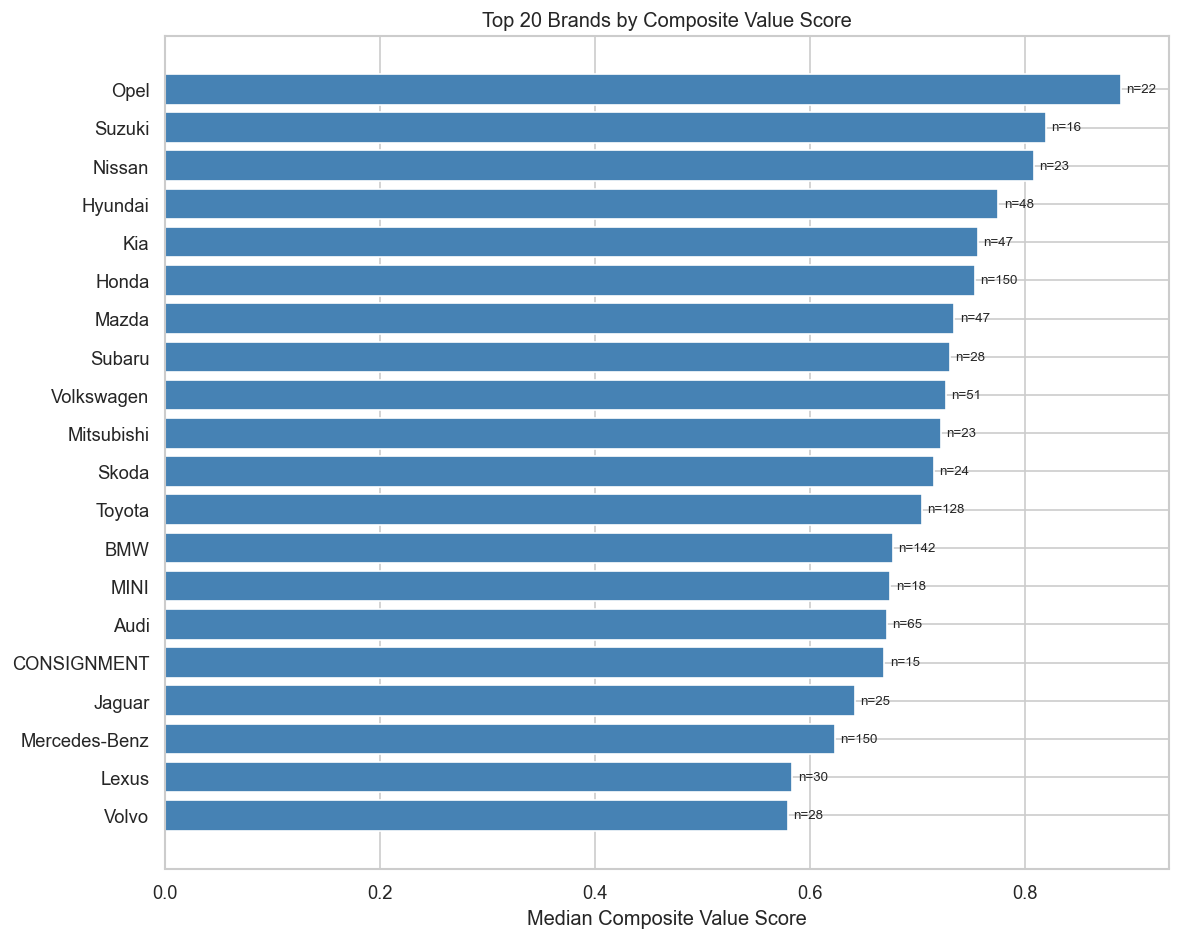

## Top 30 Brands by Composite Value Score

1. **Opel** — Score: 0.890 | $75,800 median | 18.2% depr | 53.6% retention (22 listings)
2. **Suzuki** — Score: 0.819 | $73,344 median | 20.8% depr | 46.1% retention (16 listings)
3. **Nissan** — Score: 0.808 | $70,800 median | 21.3% depr | 44.9% retention (23 listings)
4. **Hyundai** — Score: 0.776 | $68,800 median | 22.5% depr | 41.8% retention (48 listings)
5. **Kia** — Score: 0.756 | $66,800 median | 23.8% depr | 40.0% retention (47 listings)
6. **Honda** — Score: 0.754 | $68,800 median | 24.0% depr | 39.7% retention (150 listings)
7. **Mazda** — Score: 0.734 | $67,888 median | 24.3% depr | 38.4% retention (47 listings)
8. **Subaru** — Score: 0.731 | $72,000 median | 25.0% depr | 38.1% retention (28 listings)
9. **Volkswagen** — Score: 0.727 | $69,800 median | 24.8% depr | 37.4% retention (51 listings)
10. **Mitsubishi** — Score: 0.722 | $66,800 median | 25.3% depr | 37.3% retention (23 listings)


In [14]:
brand_composite = clean_scored.groupby('brand').agg(
    count=('id', 'count'), median_score=('composite_score', 'median'),
    median_price=('price', 'median'), median_depr_rate=('depreciation_rate', 'median'),
    median_retention=('value_retention', 'median'), median_ppy=('price_per_coe_year', 'median'),
).query('count >= 10').sort_values('median_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(brand_composite))
plot_brands = brand_composite.head(top_n)
ax.barh(range(len(plot_brands)), plot_brands['median_score'], color='steelblue')
ax.set_yticks(range(len(plot_brands)))
ax.set_yticklabels(plot_brands.index); ax.invert_yaxis()
ax.set_xlabel('Median Composite Value Score')
ax.set_title(f'Top {top_n} Brands by Composite Value Score')
for i, (_, row) in enumerate(plot_brands.iterrows()):
    ax.text(row['median_score'] + 0.005, i, f"n={int(row['count'])}", va='center', fontsize=8)
plt.tight_layout(); plt.show()

print('## Top 30 Brands by Composite Value Score\n')
for i, (brand, row) in enumerate(brand_composite.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — Score: {row['median_score']:.3f} | "
          f"${row['median_price']:,.0f} median | "
          f"{row['median_depr_rate']:.1%} depr | "
          f"{row['median_retention']:.1%} retention ({int(row['count'])} listings)")

## Summary & Caveats

### Data Filters Applied
- Price bracket: SGD $60K–$80K
- Registration year >= 2016 (API filter)
- Vehicle type: All Passenger Cars (`vts=2`) — excludes vans/commercial
- COE-renewed cars excluded (title-based post-filter)

### Key Findings
The analysis identifies cars and brands offering the best value across three dimensions:
1. **Lowest depreciation rate** — cheapest to own annually relative to purchase price
2. **Highest value retention** — cars that have held their original value best
3. **Lowest price per COE year** — best price per year of remaining usable life
4. **Composite score** — balanced ranking combining all three

### Data Limitations
- **Depreciation is seller-stated**, not independently computed
- **Estimated original price** is a rough linear extrapolation (`price + depreciation * age`)
- **OMV, ARF, dereg_value** are available via the detail-page scraper but require per-car page loads
- **COE category** (Cat A/B) is not captured
- The data represents a **single snapshot** (2026-05-23); trends over time may differ